In [15]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra 

## Definitions

In [16]:
# constants
R = 8.314       # J/(mol*K)     
T = 300.0       # K
C_a = 59.187    # s^-1
p_ref = 1.0e6   # 1MPA
ρ_sat = 7259.0  # kg/m^3
ρ_e = 7165.0    # kg/m^3
E_a = 21179.6   # J/mol
ϵ = 0.4         # unitless, measure of porosity
A_hoffman = 10.7    # unitless
B_hoffman = 3704.6  # K

# A = C_a * exp(-E_a/(R*T)) * (p_ref/(R*T))^A_t
A_a = C_a * exp(-E_a/(R*T))
p_eqa = p_ref * exp(A_hoffman-B_hoffman/T)

ρ_in = 4.0 * p_eqa / (R * T)

println("A_a = ", A_a, " s^-1")
println("p_eqa = ", p_eqa, " Pa")

A_a = 0.012144991086083792 s^-1
p_eqa = 192306.14595250844 Pa


In [17]:
# Time integration parameters
dt = 1e-4
dt_save = 3.0
T1 = 200.0;

save_every = Int(round(dt_save / dt)) 
nsteps = Int(round(T1 / dt_save))

67

## grid

In [18]:
# generates grid
grid = generate_grid(Line, (1,), Vec((0.0,)), Vec((1.0,)))

# generate the same 
qr = QuadratureRule{RefLine}(3)
fr = FacetQuadratureRule{RefLine}

# rho, rho_s, and v
ip_rho = Lagrange{RefLine, 1}()
cellvalues_rho = CellValues(qr, ip_rho);

ip_rho_s = Lagrange{RefLine, 1}()
cellvalues_rho_s = CellValues(qr, ip_rho_s);


In [19]:
# degree of freedom handler
dh = DofHandler(grid)
add!(dh, :rho, ip_rho)
add!(dh, :rho_s, ip_rho_s)
close!(dh);

# constraint handler
ch = ConstraintHandler(dh)
close!(ch)
update!(ch, 0.0)

In [20]:
# for debugging purpuses
const rho_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho)]
    for cell in CellIterator(dh)
]...)))

const rho_s_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho_s)]
    for cell in CellIterator(dh)
]...)));

$$\dot M = \int \phi^k \log \left( \frac{RT\rho_g}{p_{eq}}\right)(\rho_{sat}-\rho_s)dx$$

In [21]:
struct RHSparams
    A::Float64
    R::Float64
    T::Float64
    ϵ::Float64
    p_eqa::Float64
    rho_sat::Float64
    dh::DofHandler
    cellvalues_rhog::CellValues
    cellvalues_rhos::CellValues
    M::SparseMatrixCSC          # {Float64,Int} ?
    ML::SparseMatrixCSC         # Linear part of mass Matrix
    rhs::Vector{Float64}        # Can start as zeros, but we do not want to allocate each time step, so we will reuse it
    rhsL::SparseMatrixCSC       # Linear part of right-hand side
    assemble_mass!::Function    # Complete assembly of the mass matrix, including the nonlinear part
    assemble_rhs!::Function     # Complete assembly of the right-hand side, including the nonlinear part
end

In [22]:
function assemble_mass!(
        M::SparseMatrixCSC,
        u::Vector{Float64},
        params::RHSparams
    )
    copyto!(M, params.ML)  # set M equal to the linear part of the mass matrix, which is constant in time
    return M
end

assemble_mass! (generic function with 1 method)

In [23]:
function assemble_rhs!(
    N::Vector{Float64},
    u::Vector{Float64},
    params::RHSparams
)

    N .= params.rhsL * u # This line computes the linear part of the right-hand side by multiplying the linear part of the right-hand side matrix (params.rhsL) with the solution vector (u). The result is stored in N, which represents the complete right-hand side vector for the system of equations.

    # now for the non-linear part:

    rhog_dofs = dof_range(params.dh, :rho)
    rhos_dofs = dof_range(params.dh, :rho_s)

    for cell in CellIterator(params.dh)

        cell_dofs = celldofs(cell)

        rhog_local = view(u, cell_dofs[rhog_dofs])
        rhos_local = view(u, cell_dofs[rhos_dofs])

        Ferrite.reinit!(params.cellvalues_rhog, cell)
        Ferrite.reinit!(params.cellvalues_rhos, cell)

        for q in 1:getnquadpoints(params.cellvalues_rhog)

            dx = getdetJdV(params.cellvalues_rhog,q)

            # calculate the values of rhog, rhos, v, and ∂v at the quadrature point
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:length(rhog_local)
            )

            rhos_q = sum(
                rhos_local[j] *
                shape_value(params.cellvalues_rhos,q,j)
                for j in 1:length(rhos_local)
            )

            # dot m =       A*log(       R*       T*rhog  /       p_eqa)*(       rho_sat-rhos)
            mdot_q = params.A*log(params.R*params.T*rhog_q/params.p_eqa)*(params.rho_sat-rhos_q)
            for i in 1:length(rhog_local)
                ψ = shape_value(params.cellvalues_rhog,q,i)
                N[cell_dofs[rhog_dofs[i]]] -= ψ*mdot_q*dx
            end

            for i in 1:length(rhos_local)
                ψ = shape_value(params.cellvalues_rhos,q,i)
                N[cell_dofs[rhos_dofs[i]]] += ψ*mdot_q*dx
            end
        end
    end



    return N
end

assemble_rhs! (generic function with 1 method)

In [26]:
function doassemble_M_rho!(
    M_rho::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rho_s::CellValues,
    ϵ::Float64,
    dh::DofHandler
    )

    # number of basis functions per field, initialize Me
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rho_s  = getnbasefunctions(cellvalues_rho_s)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(M_rho)
    rho_dofs = dof_range(dh, :rho)
    rhos_dofs  = dof_range(dh, :rho_s)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for rho
        cell_dofs = celldofs(cell)
        fill!(Me,0)
        
        # rho
        Ferrite.reinit!(cellvalues_rho, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)
            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q_point, i)
                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q_point, j)
                    # pim pam pet
                    Me[rho_dofs[i], rho_dofs[j]] += ϵ * psi_i * psi_j * dx
                end
            end
        end

        # rhos
        Ferrite.reinit!(cellvalues_rho_s, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho_s)
            dx = getdetJdV(cellvalues_rho_s, q_point)
            for i in 1:n_basefuncs_rho_s
                psi_i = shape_value(cellvalues_rho_s, q_point, i)
                for j in 1:n_basefuncs_rho_s
                    psi_j = shape_value(cellvalues_rho_s, q_point, j)
                    # pim pam pet
                    Me[rhos_dofs[i], rhos_dofs[j]] += (1-ϵ) * psi_i * psi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Me)
    end
    return M_rho
end


doassemble_M_rho! (generic function with 2 methods)

In [27]:
# State vectors
ndofs_total = ndofs(dh)
u      = zeros(ndofs_total)
rhs    = similar(u)

# Initialization of matrices
# Assemble linear matrices
ML    = allocate_matrix(dh)
M     = allocate_matrix(dh)
rhsL  = allocate_matrix(dh)

doassemble_M_rho!(ML, cellvalues_rho, cellvalues_rho_s, ϵ, dh)

# Linear parts of rhs
fill!(rhsL, 0.0)

# Initial condition
apply_analytical!(u, dh, :rho, x -> ρ_in)
apply_analytical!(u, dh, :rho_s, x -> ρ_e)

# Initial BC application
update!(ch, 0.0)
apply!(u, ch);


In [28]:
params = RHSparams(
    A_a, 
    R, 
    T, 
    ϵ,
    p_eqa, 
    ρ_sat, 
    dh, 
    cellvalues_rho, 
    cellvalues_rho_s, 
    M,
    ML,
    rhs,
    rhsL,
    assemble_mass!,
    assemble_rhs!    
)

RHSparams(0.012144991086083792, 8.314, 300.0, 0.4, 192306.14595250844, 7259.0, DofHandler{1, Grid{1, Line, Float64}}(SubDofHandler{DofHandler{1, Grid{1, Line, Float64}}}[SubDofHandler{DofHandler{1, Grid{1, Line, Float64}}}(DofHandler{1, Grid{1, Line, Float64}}(#= circular reference @-3 =#), OrderedCollections.OrderedSet{Int64}([1]), [:rho, :rho_s], Interpolation[Lagrange{RefLine, 1}(), Lagrange{RefLine, 1}()], Int64[], 4)], [:rho, :rho_s], [1, 2, 3, 4], [1], [1], true, Grid{1, Line, Float64}(Line[Line((1, 2))], Node{1, Float64}[Node{1, Float64}([0.0]), Node{1, Float64}([1.0])], Dict{String, OrderedCollections.OrderedSet{Int64}}(), Dict{String, OrderedCollections.OrderedSet{Int64}}(), Dict{String, OrderedCollections.OrderedSet{FacetIndex}}("left" => OrderedCollections.OrderedSet{FacetIndex}([FacetIndex((1, 1))]), "right" => OrderedCollections.OrderedSet{FacetIndex}([FacetIndex((1, 2))])), Dict{String, OrderedCollections.OrderedSet{VertexIndex}}()), 4), CellValues{Ferrite.FunctionValues{

In [29]:
function res!(res, du, u, params, t)

    params.assemble_mass!(params.M, u, params)
    params.assemble_rhs!(params.rhs, u, params)

    mul!(res, params.M, du)      # res = M*du
    res .-= params.rhs

    update!(ch, t)
    for k in 1:length(ch.prescribed_dofs)
        dof = ch.prescribed_dofs[k]
        value = ch.inhomogeneities[k]
        res[dof] = u[dof] - value
    end

end

res! (generic function with 1 method)

In [30]:
using DifferentialEquations

In [31]:
# enforce initial state
update!(ch, 0.0)
apply!(u, ch)          

dt = 1e-6

params.assemble_rhs!(params.rhs, u, params)
params.assemble_mass!(params.M, u, params)

B = params.rhs * dt + (params.M * u)
A = copy(params.M)
apply!(A, B, ch)

u_new = A \ B
du = ( u_new - u) / dt

4-element Vector{Float64}:
 -3.9565850329381647
 -3.95658526031184
  2.637725629028864
  2.637722900544759

In [32]:
rest = zeros(ndofs_total)
res!(rest, du, u, params, 0.0)

println("res = ", sum(rest))

res = 5.002220858640882e-7


In [33]:
differential_vars = trues(length(u))
tspan = (0.0, T1)


prob = DAEProblem(
    res!,
    du,
    u,
    tspan,
    params;
    differential_vars=differential_vars
)

sol = solve(
    prob, 
    saveat=dt_save,
    reltol=1e-6,
    abstol=1e-6
)


retcode: Success
Interpolation: 1st order linear
t: 68-element Vector{Float64}:
   0.0
   3.0
   6.0
   9.0
  12.0
  15.0
  18.0
  21.0
  24.0
  27.0
  30.0
  33.0
  36.0
   ⋮
 168.0
 171.0
 174.0
 177.0
 180.0
 183.0
 186.0
 189.0
 192.0
 195.0
 198.0
 200.0
u: 68-element Vector{Vector{Float64}}:
 [308.4053338986584, 308.4053338986584, 7165.0, 7165.0]
 [297.16848844607347, 297.1684884460736, 7172.491230301724, 7172.491230301724]
 [287.0879906807224, 287.08799068072256, 7179.211562145291, 7179.211562145291]
 [278.01404224795704, 278.01404224795743, 7185.260861100469, 7185.260861100469]
 [269.8205619444923, 269.8205619444927, 7190.723181302778, 7190.723181302778]
 [262.40038717453405, 262.40038717453456, 7195.66996448275, 7195.66996448275]
 [255.66206446963136, 255.66206446963187, 7200.162179619351, 7200.162179619351]
 [249.5270138380027, 249.5270138380032, 7204.252213373771, 7204.252213373771]
 [243.92750418608568, 243.92750418608634, 7207.985219808384, 7207.985219808384]
 [238.8049299

In [34]:
function alles(ϵ)
    # constants
    R = 8.314       # J/(mol*K)     
    T = 300.0       # K
    C_a = 59.187    # s^-1
    p_ref = 1.0e6   # 1MPA
    ρ_sat = 7259.0  # kg/m^3
    ρ_e = 7165.0    # kg/m^3
    E_a = 21179.6   # J/mol
    # ϵ = 0.4         # unitless, measure of porosity
    A_hoffman = 10.7    # unitless
    B_hoffman = 3704.6  # K

    # A = C_a * exp(-E_a/(R*T)) * (p_ref/(R*T))^A_t
    A_a = C_a * exp(-E_a/(R*T))
    p_eqa = p_ref * exp(A_hoffman-B_hoffman/T)

    ρ_in = 4.0 * p_eqa / (R * T)

    # Time integration parameters
    dt = 1e-4
    dt_save = 3.0
    T1 = 200.0;

    save_every = Int(round(dt_save / dt)) 
    nsteps = Int(round(T1 / dt_save))

    # generates grid
    grid = generate_grid(Line, (1,), Vec((0.0,)), Vec((1.0,)))

    # generate the same 
    qr = QuadratureRule{RefLine}(3)
    fr = FacetQuadratureRule{RefLine}

    # rho, rho_s, and v
    ip_rho = Lagrange{RefLine, 1}()
    cellvalues_rho = CellValues(qr, ip_rho);

    ip_rho_s = Lagrange{RefLine, 1}()
    cellvalues_rho_s = CellValues(qr, ip_rho_s);

    # degree of freedom handler
    dh = DofHandler(grid)
    add!(dh, :rho, ip_rho)
    add!(dh, :rho_s, ip_rho_s)
    close!(dh);

    # constraint handler
    ch = ConstraintHandler(dh)
    close!(ch)
    update!(ch, 0.0)

    # State vectors
    ndofs_total = ndofs(dh)
    u      = zeros(ndofs_total)
    rhs    = similar(u)

    # Initialization of matrices
    # Assemble linear matrices
    ML    = allocate_matrix(dh)
    M     = allocate_matrix(dh)
    rhsL  = allocate_matrix(dh)

    doassemble_M_rho!(ML, cellvalues_rho, cellvalues_rho_s, ϵ, dh)

    # Linear parts of rhs
    fill!(rhsL, 0.0)

    # Initial condition
    apply_analytical!(u, dh, :rho, x -> ρ_in)
    apply_analytical!(u, dh, :rho_s, x -> ρ_e)

    # Initial BC application
    update!(ch, 0.0)
    apply!(u, ch);

    params = RHSparams(
        A_a, 
        R, 
        T, 
        ϵ,
        p_eqa, 
        ρ_sat, 
        dh, 
        cellvalues_rho, 
        cellvalues_rho_s, 
        M,
        ML,
        rhs,
        rhsL,
        assemble_mass!,
        assemble_rhs!    
    )

    # enforce initial state
    update!(ch, 0.0)
    apply!(u, ch)         

    dt = 1e-6

    params.assemble_rhs!(params.rhs, u, params)
    params.assemble_mass!(params.M, u, params)

    B = params.rhs * dt + (params.M * u)
    A = copy(params.M)
    apply!(A, B, ch)

    u_new = A \ B
    du = ( u_new - u) / dt

    differential_vars = trues(length(u))
    tspan = (0.0, T1)


    prob = DAEProblem(
        res!,
        du,
        u,
        tspan,
        params;
        differential_vars=differential_vars
    )

    sol = solve(
        prob, 
        saveat=dt_save,
        reltol=1e-6,
        abstol=1e-6
    )
    return sol
end

alles (generic function with 1 method)

In [35]:
epsilon_four = alles(0.4)
epsilon_five = alles(0.5)
epsilon_six = alles(0.6);

## Plotting/animating

In [184]:
using Plots

In [61]:
U_four = Array(epsilon_four);
U_five = Array(epsilon_five);
U_six = Array(epsilon_six);

sol_ρ_four = U_four[rho_global, :]
sol_ρ_s_four = U_four[rho_s_global, :]

sol_ρ_five = U_five[rho_global, :]
sol_ρ_s_five = U_five[rho_s_global, :]

sol_ρ_six = U_six[rho_global, :]
sol_ρ_s_six = U_six[rho_s_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ_four, 1))
discrete_t = sol.t #range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρgmax = maximum(sol_ρ_four)
ρsmax = maximum(sol_ρ_s_four)
ρmax = maximum([ρgmax, ρsmax])
ρmin = minimum(sol_ρ_four)

170.62079171965834

In [ ]:
p1 = plot(
    discrete_t, 
    sol_ρ_four[1,:], 
    label="ρg, ϵ=0.4", 
    xlabel="Time (s)", 
    ylabel="Density (kg/m^3)", 
    title="ρg over time for different ϵ values", 
    legend=:topright
)

plot!(p1, discrete_t, sol_ρ_five[1,:], label="ρg, ϵ=0.5")
plot!(p1, discrete_t, sol_ρ_s_four[1,:], label="ρs, ϵ=0.4")

p2 = plot(
    discrete_t, 
    sol_ρ_s_five[1,:], 
    label="ρs, ϵ=0.5", 
    xlabel="Time (s)", 
    ylabel="Density (kg/m^3)", 
    title="ρs over time for different ϵ values", 
    legend=:topright

)
plot!(p2, discrete_t, sol_ρ_s_six[1,:], label="ρs, ϵ=0.6")
plot!(p2, discrete_t, sol_ρ_s_four[1,:], label="ρs, ϵ=0.4")

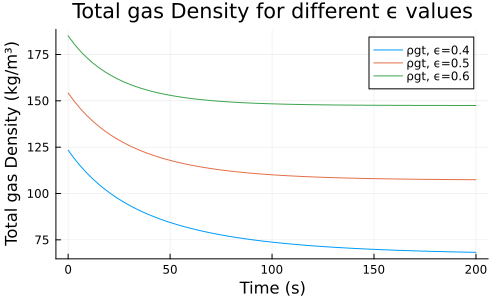

In [90]:
p1 = plot(
    discrete_t, 
    sol_ρ_four[1,:]*0.4, 
    label="ρgt, ϵ=0.4", 
    xlabel="Time (s)", 
    ylabel="Total gas Density (kg/m³)", 
    title="Total gas Density for different ϵ values", 
    legend=:topright,
    size=(500, 300)
)

plot!(p1, discrete_t, sol_ρ_five[1,:]*0.5, label="ρgt, ϵ=0.5")
plot!(p1, discrete_t, sol_ρ_six[1,:]*0.6, label="ρgt, ϵ=0.6")

In [91]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_1_epsilon_gas.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_1_epsilon_gas.png"

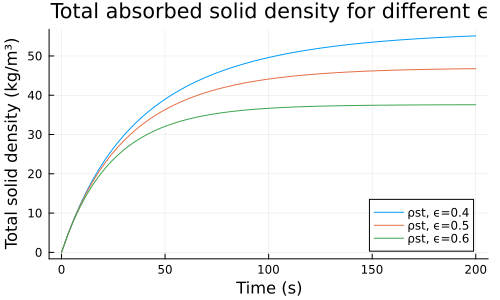

In [88]:
p2 = plot(
    discrete_t, 
    (sol_ρ_s_four[1,:].-ρ_e)*(1-0.4), 
    label="ρst, ϵ=0.4", 
    xlabel="Time (s)", 
    ylabel="Total solid density (kg/m³)", 
    title="Total absorbed solid density for different ϵ", 
    legend=:bottomright,
    size=(500, 300)
)
plot!(p2, discrete_t, (sol_ρ_s_five[1,:].-ρ_e)*0.5, label="ρst, ϵ=0.5")
plot!(p2, discrete_t, (sol_ρ_s_six[1,:].-ρ_e)*(1-0.6), label="ρst, ϵ=0.6")


In [89]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_1_epsilon_solid.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_1_epsilon_solid.png"

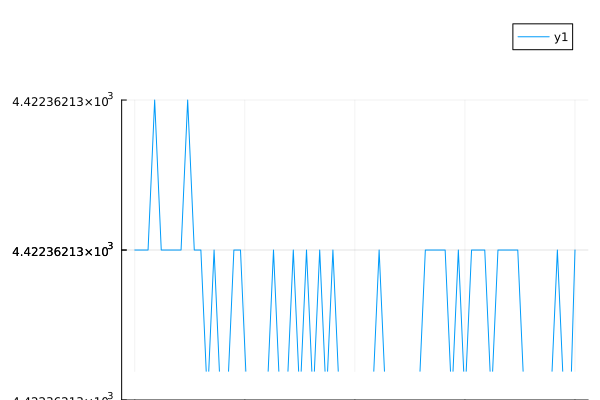

GKS: Possible loss of precision in routine SET_WINDOW


In [ ]:
plot(discrete_t,
sol_ρ_four[1,:]*0.4.+sol_ρ_s_four[1,:]*0.6)

In [186]:
dts = diff(sol.t)

75-element Vector{Float64}:
 5.5272923881584993e-5
 5.5272923881584993e-5
 0.00011054584776316999
 0.00022109169552633997
 0.00044218339105267995
 0.0008843667821053599
 0.0017687335642107198
 0.0035374671284214396
 0.007074934256842879
 0.014149868513685758
 0.028299737027371517
 0.05659947405474303
 0.11319894810948607
 ⋮
 6.634009708287564
 6.634009708287579
 6.634009708287579
 6.634009708287579
 6.634009708287579
 6.634009708287579
 6.634009708287579
 6.634009708287579
 6.634009708287579
 6.634009708287579
 6.634009708287579
 1.853732704266747

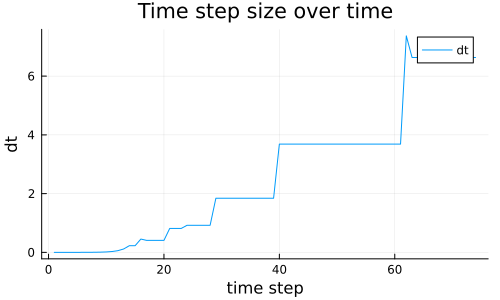

In [ ]:
plot(dts[1:end-1], label="dt", xlabel="time step", 
ylabel="dt", title="Time step size over time", size=(500, 300), legend=:topright)

In [191]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_1_time_step_size.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_1_time_step_size.png"

In [135]:
foldername = name

U = Array(sol)

sol_ρ = U[rho_global, :]
sol_ρ_s = U[rho_s_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = sol.t #range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρgmax = maximum(sol_ρ)
ρsmax = maximum(sol_ρ_s)
ρmax = maximum([ρgmax, ρsmax])
ρmin = minimum(sol_ρ)


170.62079171965834

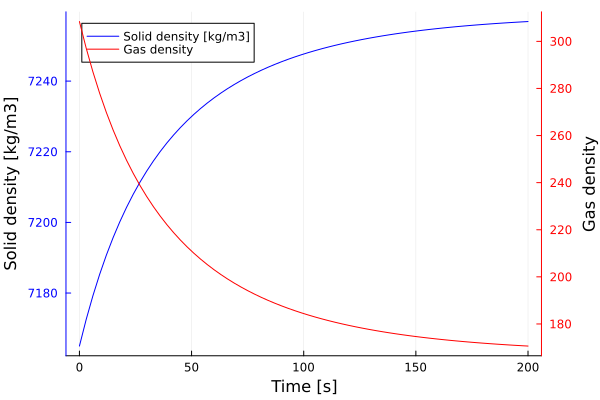

In [151]:
p = plot(
    discrete_t,
    sol_ρ_s[1, :],
    label="Solid density [kg/m3]",
    xlabel="Time [s]",
    ylabel="Solid density [kg/m3]",
    color=:blue,
    y_foreground_color_text=:blue,
    y_foreground_color_axis=:blue,
    y_foreground_color_border=:blue,
)

# Actual data on the right axis, but no legend entry
plot!(
    twinx(),
    discrete_t,
    sol_ρ[1, :],
    color = :red,
    y_foreground_color_text=:red,
    y_foreground_color_axis=:red,
    y_foreground_color_border=:red,
    ylabel = "Gas density",
    label = false,
)

# Dummy series for the legend
plot!(
    p,
    [NaN], [NaN],
    color = :red,
    label = "Gas density",
)

In [ ]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_1_constant_gas_absorption.png"
savefig(joinpath(folder, name))

2×68 Matrix{Float64}:
 7165.0  7172.59  7179.57  7185.99  …  7258.57  7258.6  7258.63  7258.65
 7165.0  7172.59  7179.57  7185.99     7258.57  7258.6  7258.63  7258.65

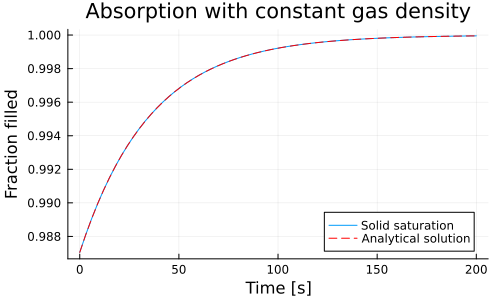

In [160]:
# Plot 1: Constant gas density
p1 = plot(
    discrete_t,
    sol_ρ_s_constant_gas[1, :] ./ ρ_sat,
    xlabel = "Time [s]",
    ylabel = "Fraction filled",
    label = "Solid saturation",
    title = "Absorption with constant gas density",
    size = (500, 300),
    legend = :bottomright
)

k = A_a * log(ρ_in * R * T / p_eqa) / (1 - ϵ)
fill_fraction_analytical = [
    ρ_sat - (ρ_sat - ρ_e) * exp(-k * t) for t in discrete_t
]

plot!(
    p1,
    discrete_t,
    fill_fraction_analytical ./ ρ_sat,
    label = "Analytical solution",
    color = :red,
    linestyle = :dash,
)

In [161]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_1_constant_gas_absorption.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_1_constant_gas_absorption.png"

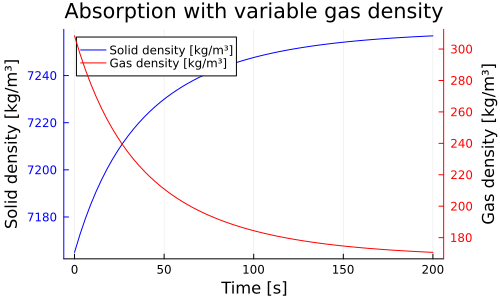

In [162]:
# Plot 2: Variable gas density
p2 = plot(
    discrete_t,
    sol_ρ_s[1, :],
    label = "Solid density [kg/m³]",
    xlabel = "Time [s]",
    ylabel = "Solid density [kg/m³]",
    title = "Absorption with variable gas density",
    color = :blue,
    y_foreground_color_text = :blue,
    y_foreground_color_axis = :blue,
    y_foreground_color_border = :blue,
    size = (500, 300)
)

plot!(
    twinx(),
    discrete_t,
    sol_ρ[1, :],
    color = :red,
    ylabel = "Gas density [kg/m³]",
    label = false,
    y_foreground_color_text = :red,
    y_foreground_color_axis = :red,
    y_foreground_color_border = :red,
)

# Dummy legend entry
plot!(
    p2,
    [NaN], [NaN],
    color = :red,
    label = "Gas density [kg/m³]",
)


In [163]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_1_variable_gas_absorption.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_1_variable_gas_absorption.png"

In [200]:
println("ρ_e = ", ρ_e, ", ρ_sat = ", ρ_sat)

ρ_e = 7165.0, ρ_sat = 7259.0


In [ ]:
sol_ρ_s[1, 1]

7177.193471664117

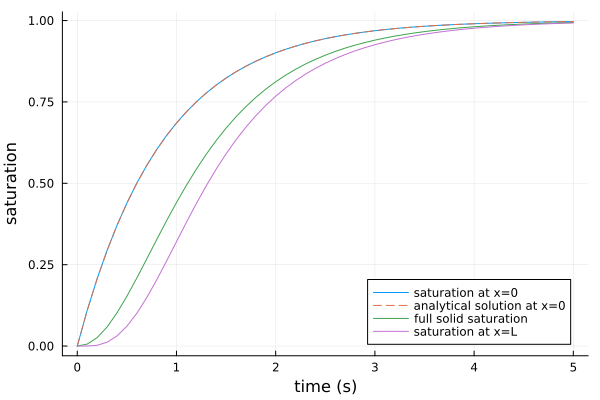

In [97]:
plot(
    sol.t,
    sol_ρ_s[1, :],
    xlabel = "time (s)",
    ylabel = "saturation",
    label = "saturation at x=0",
    legend=:bottomright
)
k = log(2)/(1-ϵ)
plot!(
    sol.t,
    1.0 .- 1 .* exp.(-k.*sol.t),
    label = "analytical solution at x=0",
    linestyle = :dash
)

plot!(
    sol.t,
    fill_fraction/(1-ϵ),
    # xlabel = "time",
    # ylabel = "fraction filled",
    label = "full solid saturation"
    )

plot!(
    sol.t,
    sol_ρ_s[end, :],
    # xlabel = "time",
    # ylabel = "solid density [kg/m^3]",
    label = "saturation at x=L"
)


In [172]:
savefig(joinpath(foldername, "fill_fraction.png"))

"c:\\Users\\noudh\\uni\\MEP\\4. fem model two\\e. differential equations implemetations\\fill_fraction.png"

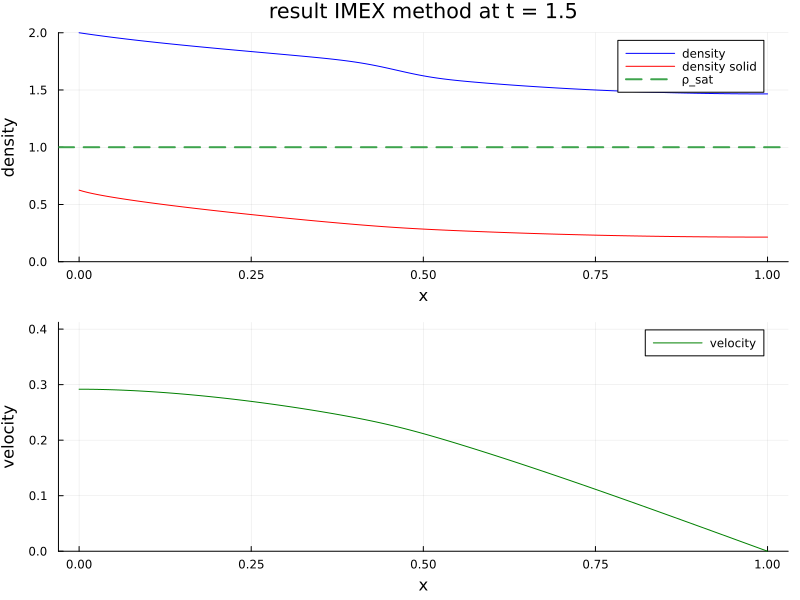

In [22]:
k = 15

# top plot: density + total pressure
p1 = plot(
    discrete_x,
    sol_ρ[:, k],
    label="density",
    color=:blue,
    xlabel="x",
    ylabel="density",
    title="result IMEX method at t = $(round(discrete_t[k], digits=3))",
    ylims=(0, ρmax),
    legend=:topright
)

plot!(
    p1,
    discrete_x,
    sol_ρ_s[:, k],
    label="density solid",
    color=:red,
)

p2 = plot(
    discrete_x,
    sol_v[:, k],
    label="velocity",
    color=:green,
    xlabel="x",
    ylabel="velocity",
    ylims=(vmin, vmax),
    legend=:topright
)

hline!(p1, 
    [rho_sat],
    label = "ρ_sat",
    lw = 2,
    # color = :green,
    linestyle = :dash)

plot(p1, p2, layout=(2,1), size=(800,600))

In [23]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_4_result_IMEX.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_4_result_IMEX.png"

### Ugly plots below

# Debugging

In [ ]:
# debugging
doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
doassemble_N!(N, u, cellvalues_rho, cellvalues_v, facetvalues, left, dh)

In [18]:
# debugging
display(Matrix(M_rho[rho_global, rho_global]))
display(Matrix(D[v_global, v_global]))
display(Matrix(P[
    v_global ,
    rho_global
    ]))
display(Matrix(M_v[v_global, v_global]))

201×201 Matrix{Float64}:
 0.00166667   0.000833333  0.0          …  0.0          0.0
 0.000833333  0.00333333   0.000833333     0.0          0.0
 0.0          0.000833333  0.00333333      0.0          0.0
 0.0          0.0          0.000833333     0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0          …  0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0          …  0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 ⋮                                      ⋱               ⋮
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0          …  0.0          0.0
 0.0          0.0

201×201 Matrix{Float64}:
 -200.0   200.0     0.0     0.0     0.0  …     0.0     0.0     0.0     0.0
  200.0  -400.0   200.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0   200.0  -400.0   200.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0   200.0  -400.0   200.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0   200.0  -400.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0   200.0  …     0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0  …     0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0


201×201 Matrix{Float64}:
 5.0  -5.0   0.0           0.0          …   0.0   0.0   0.0   0.0   0.0   0.0
 5.0   0.0  -5.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   5.0  -8.88178e-16  -5.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   5.0           8.88178e-16      0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           5.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0          …   0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0          …   0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0         

201×201 Matrix{Float64}:
 0.00333333  0.00166667  0.0         …  0.0         0.0         0.0
 0.00166667  0.00666666  0.00166666     0.0         0.0         0.0
 0.0         0.00166666  0.00666664     0.0         0.0         0.0
 0.0         0.0         0.00166666     0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0         …  0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0         …  0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 ⋮                                   ⋱                          ⋮
 0.0         0.0         

In [ ]:
# debugging

# --------------------------------------------------
# Assemble constant matrices
# --------------------------------------------------
M_rho = allocate_matrix(dh)
M_v   = allocate_matrix(dh)
D     = allocate_matrix(dh)
P     = allocate_matrix(dh)

doassemble_M_rho!(M_rho, cellvalues_rho, dh)
doassemble_D!(D, cellvalues_v, dh)
doassemble_P!(P, cellvalues_v, cellvalues_rho, dh)

A_lin = -P - D + M_rho/dt
B_lin = M_rho/dt

# --------------------------------------------------
# Initial condition
# --------------------------------------------------
ndofs_total = ndofs(dh)

u   = zeros(ndofs_total)
rhs = zeros(ndofs_total)
N   = zeros(ndofs_total)

apply_analytical!(u, dh, :rho, x -> 1.0)
apply_analytical!(u, dh, :v,   x -> 0.0)

update!(ch, 0.0)
apply!(u, ch)

println("Initial u:")
display(u)

# --------------------------------------------------
# Assemble nonlinear pieces at IC
# --------------------------------------------------
fill!(M_v, 0.0)
fill!(N, 0.0)

doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
doassemble_N!(N, u, cellvalues_rho, cellvalues_v,
              facetvalues, left, dh)

println("||N|| = ", norm(N))

# --------------------------------------------------
# Build system
# --------------------------------------------------
A = copy(A_lin)
B = copy(B_lin)

A .+= M_v/dt
B .+= M_v/dt

rhs .= B*u + N

println("norm(rhs) = ", norm(rhs))

# --------------------------------------------------
# Apply BCs
# --------------------------------------------------
update!(ch, dt)

rhsdata = get_rhs_data(ch, A)

A_bc   = copy(A)
rhs_bc = copy(rhs)

apply!(A_bc, ch)
apply_rhs!(rhsdata, rhs_bc, ch)

# --------------------------------------------------
# Diagnostics
# --------------------------------------------------
println("size(A) = ", size(A_bc))
println("rank estimate = ", rank(Matrix(A_bc)))

println("minimum diag(A) = ", minimum(diag(A_bc)))
println("maximum diag(A) = ", maximum(diag(A_bc)))

# --------------------------------------------------
# Solve ONE timestep
# --------------------------------------------------
u_new = A_bc \ rhs_bc

apply!(u_new, ch)

println("max |u_new-u| = ", maximum(abs.(u_new .- u)))

# --------------------------------------------------
# Check fields separately
# --------------------------------------------------
println("rho old:")
display(u[rho_global])

println("rho new:")
display(u_new[rho_global])

println("v old:")
display(u[v_global])

println("v new:")
display(u_new[v_global])